In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/content/data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [10]:
df.isnull().mean()*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,2.500261
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [11]:
df.shape

(19158, 13)

In [17]:
cols=[var for var in df.columns if df[var].isnull().mean()*100<5 and df[var].isnull().mean()*100>0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [19]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [22]:
new_df=df[cols].dropna()
df.shape,new_df.shape

((19158, 13), (17182, 5))

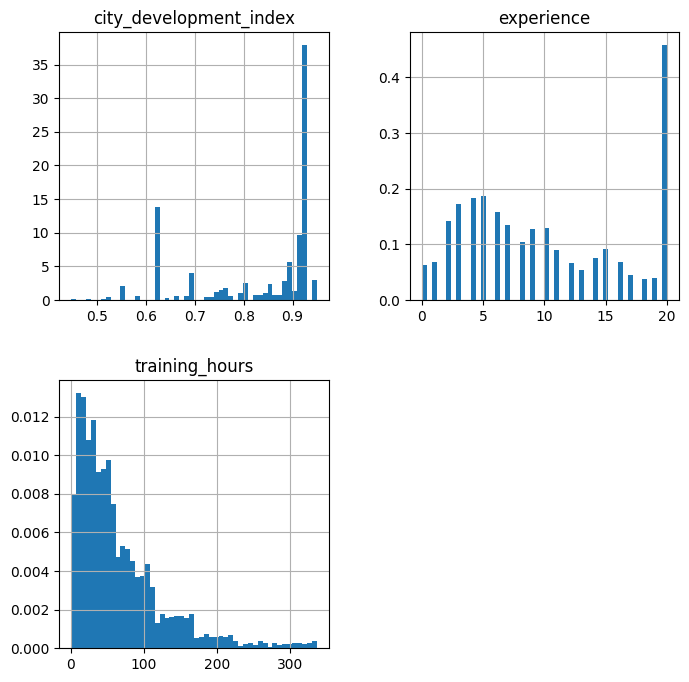

In [33]:
new_df.hist(bins=50,density=True,figsize=(8,8))
plt.show()

(array([8.00907579e-03, 1.32123691e-02, 1.30125765e-02, 1.07714251e-02,
        1.18138211e-02, 9.14702474e-03, 9.31207077e-03, 9.72902916e-03,
        7.46181790e-03, 4.71684182e-03, 5.28147298e-03, 5.14248684e-03,
        4.54310915e-03, 3.70050574e-03, 3.75262553e-03, 4.35200322e-03,
        3.16193448e-03, 1.31168161e-03, 1.78075980e-03, 1.58096724e-03,
        1.60702714e-03, 1.65914694e-03, 1.68520684e-03, 1.57228061e-03,
        1.77207317e-03, 5.21197991e-04, 5.64631157e-04, 7.38363821e-04,
        5.82004423e-04, 5.99377690e-04, 6.34124222e-04, 5.90691056e-04,
        7.03617288e-04, 3.64838594e-04, 1.30299498e-04, 1.99792563e-04,
        2.77972262e-04, 1.73732664e-04, 3.73525227e-04, 2.51912362e-04,
        8.68663318e-05, 2.95345528e-04, 1.91105930e-04, 2.08479196e-04,
        2.34539096e-04, 2.86658895e-04, 2.51912362e-04, 2.43225729e-04,
        2.95345528e-04, 3.64838594e-04]),
 array([  1. ,   7.7,  14.4,  21.1,  27.8,  34.5,  41.2,  47.9,  54.6,
         61.3,  68. ,  

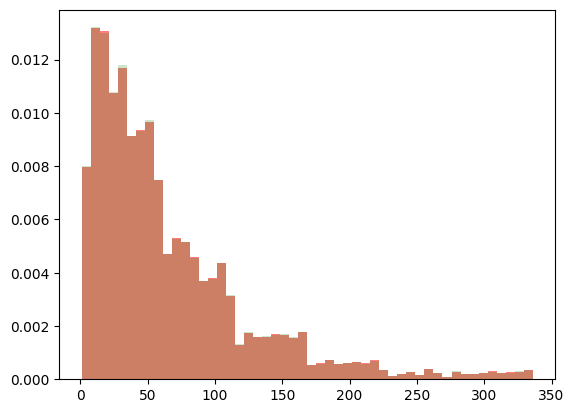

In [42]:

plt.hist(df['training_hours'],bins=50, density=True, color='red',alpha=0.5)
plt.hist(new_df['training_hours'],bins=50, density=True, color='green',alpha=0.2)


<Axes: ylabel='Density'>

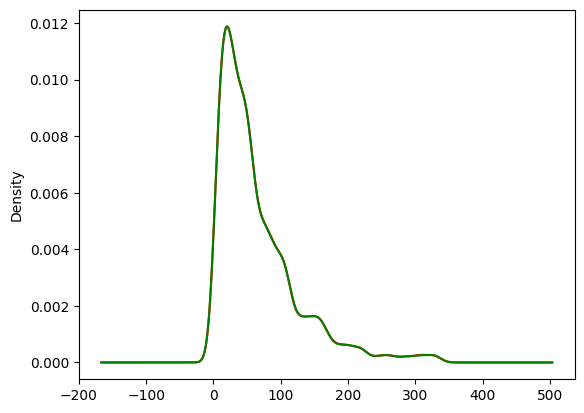

In [45]:
df['training_hours'].plot.density(color='red')
new_df['training_hours'].plot.density(color='green')

<Axes: >

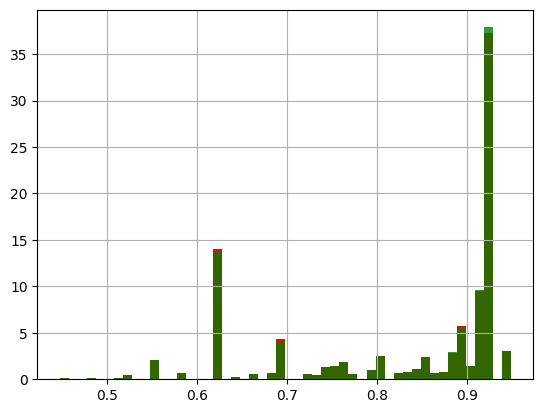

In [46]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['city_development_index'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

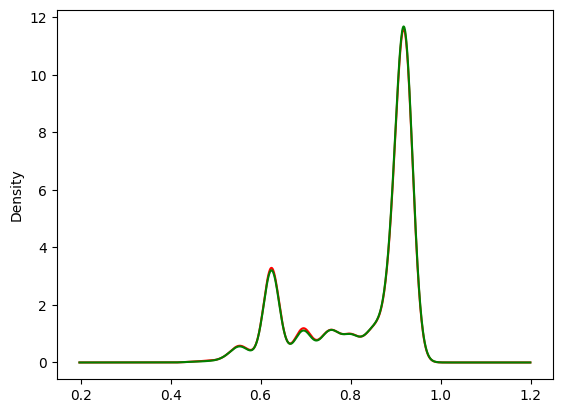

In [47]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].plot.density(color='red')

# data after cca
new_df['city_development_index'].plot.density(color='green')

In [48]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['enrolled_university'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [49]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['education_level'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp #as percentages of og and cca are near so its a valid cca

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
